In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import re

import metapredict as meta

In [2]:
clinvar = pd.read_csv('../Data/clinvar_missense.csv')
WTCRX = 'MMAYMNPGPHYSVNALALSGPSVDLMHQAVPYPSAPRKQRRERTTFTRSQLEELEALFAKTQYPDVYAREEVALKINLPESRVQVWFKNRRAKCRQQRQQQKQQQQPPGGQAKARPAKRKAGTSPRPSTDVCPDPLGISDSYSPPLPGPSGSPTTAVATVSIWSPASESPLPEAQRAGLVASGPSLTSAPYAMTYAPASAFCSSPSAYGSPSSYFSGLDPYLSPMVPQLGGPALSPLSGPSVGPSLAQSPTSLSGQSYGAYSPVDSLEFKDPTGTWKFTYNPMDPLDYKDQSAWKFQIL'

In [3]:
dScore = meta.predict_disorder(WTCRX)

In [4]:
# Extract mutation position from "Protein Change" column
def extract_position(protein_change):
    """Extract numeric position from X###Y format"""
    match = re.search(r'\d+', str(protein_change))
    return int(match.group()) if match else None

# Bin germline classifications
def bin_classification(classification):
    """Bin classifications into Pathogenic, Benign, or VUS"""
    classification = str(classification).lower()
    if any(term in classification for term in ['pathogenic/likely pathogenic', 'likely pathogenic', 'pathogenic']):
        return 'Pathogenic'
    elif any(term in classification for term in ['benign/likely benign', 'likely benign', 'benign']):
        return 'Benign'
    else:
        return 'VUS'


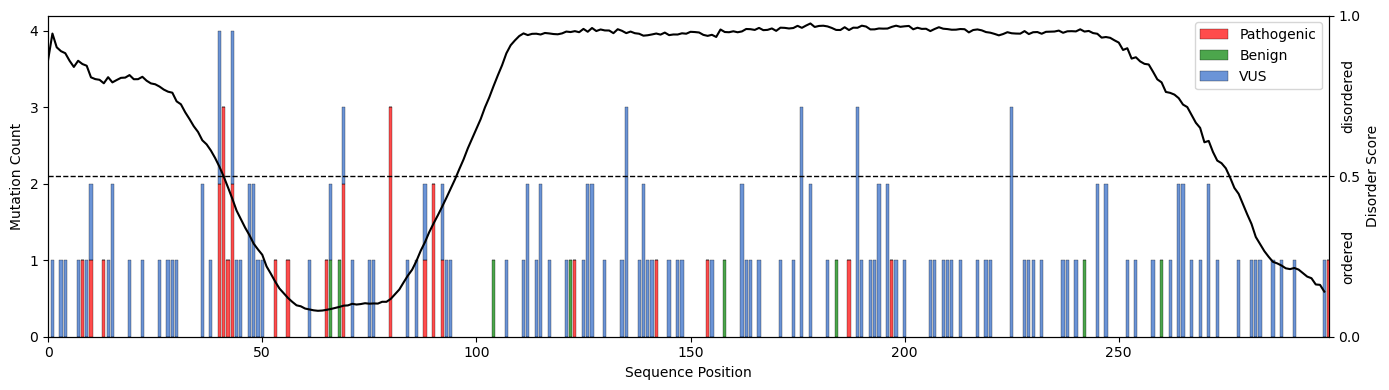

In [5]:
clinvar['Position'] = clinvar['Protein change'].apply(extract_position)
clinvar['Category'] = clinvar['Germline classification'].apply(bin_classification)

# Count mutations by position and category
mutation_counts = clinvar.groupby(['Position', 'Category']).size().unstack(fill_value=0)

# Ensure all categories exist
for cat in ['Pathogenic', 'Benign', 'VUS']:
    if cat not in mutation_counts.columns:
        mutation_counts[cat] = 0

# Create figure with two y-axes
fig, ax1 = plt.subplots(figsize=(14, 4))

# Create stacked bar plot for mutations on left axis
positions = mutation_counts.index.values
width = .75
bottom_benign = mutation_counts['Pathogenic'].values
bottom_vus = bottom_benign + mutation_counts['Benign'].values

ax1.bar(positions, mutation_counts['Pathogenic'].values, width=width, color='red', alpha=0.7, 
        label='Pathogenic', edgecolor='black', linewidth=0.3, zorder=2)
ax1.bar(positions, mutation_counts['Benign'].values, width=width, bottom=bottom_benign, 
        color='green', alpha=0.7, label='Benign', edgecolor='black', linewidth=0.3, zorder=2)
ax1.bar(positions, mutation_counts['VUS'].values, width=width, bottom=bottom_vus, 
        color="#2C67C7", alpha=0.7, label='VUS', edgecolor='black', linewidth=0.3, zorder=2)

ax1.set_xlabel('Sequence Position')
ax1.set_ylabel('Mutation Count', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xlim(0, 299)
ax1.set_yticks(range(0, int(ax1.get_ylim()[1]) + 1))
ax1.legend(loc='upper right')

# Create second y-axis for disorder score
ax2 = ax1.twinx()
ax2.plot(np.arange(dScore.shape[0]), dScore, linestyle='-', color='black', linewidth=1.5, zorder=3)
ax2.axhline(y=0.5, color='black', linestyle='--', linewidth=1, zorder=1)
ax2.set_ylabel('Disorder Score', color='black')
ax2.tick_params(axis='y', labelcolor='black')
ax2.set_ylim(0, 1)
ax2.set_yticks([0, 0.5, 1])

# Add ordered/disordered labels
ax2.text(1.01, 0.25, 'ordered', transform=ax2.get_yaxis_transform(), 
         fontsize=10, va='center', ha='left', rotation=90)
ax2.text(1.01, 0.75, 'disordered', transform=ax2.get_yaxis_transform(), 
         fontsize=10, va='center', ha='left', rotation=90)

plt.tight_layout()
#plt.savefig('../Graphs/Fig1/Res-Clinvars.svg')

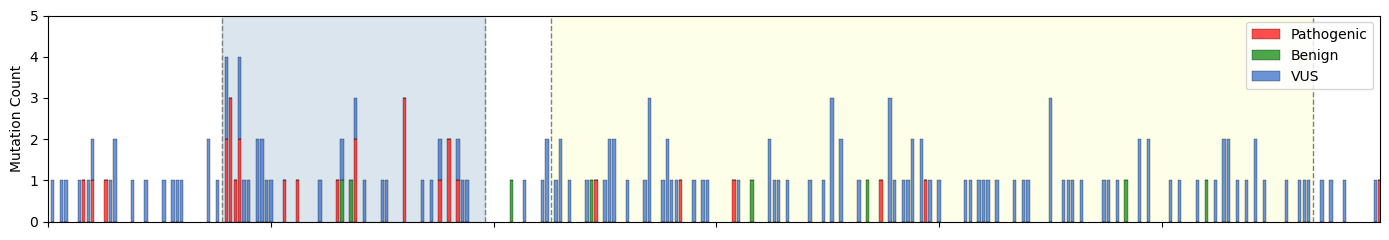

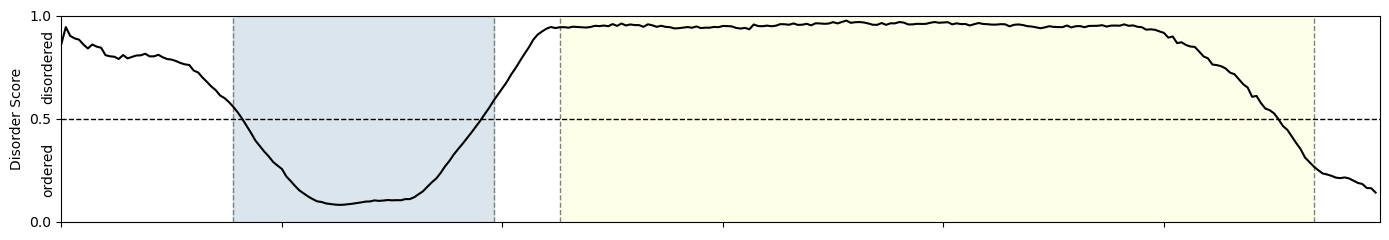

In [16]:
clinvar['Position'] = clinvar['Protein change'].apply(extract_position)
clinvar['Category'] = clinvar['Germline classification'].apply(bin_classification)

# Count mutations by position and category
mutation_counts = clinvar.groupby(['Position', 'Category']).size().unstack(fill_value=0)

# Ensure all categories exist
for cat in ['Pathogenic', 'Benign', 'VUS']:
    if cat not in mutation_counts.columns:
        mutation_counts[cat] = 0

# FIGURE 1: Mutation counts
fig1, ax1 = plt.subplots(figsize=(14, 2.5))

# Add background regions and vertical lines
ax1.axvspan(39, 98, alpha=0.2, color="#4981ae", zorder=0)
ax1.axvspan(113, 284, alpha=0.2, color="#fdff91", zorder=0)
ax1.axvline(x=39, color='grey', linestyle='--', linewidth=1, zorder=1)
ax1.axvline(x=98, color='grey', linestyle='--', linewidth=1, zorder=1)
ax1.axvline(x=113, color='grey', linestyle='--', linewidth=1, zorder=1)
ax1.axvline(x=284, color='grey', linestyle='--', linewidth=1, zorder=1)

# Create stacked bar plot for mutations
positions = mutation_counts.index.values
width = .75
bottom_benign = mutation_counts['Pathogenic'].values
bottom_vus = bottom_benign + mutation_counts['Benign'].values

ax1.bar(positions, mutation_counts['Pathogenic'].values, width=width, color='red', alpha=0.7, 
        label='Pathogenic', edgecolor='black', linewidth=0.3, zorder=2)
ax1.bar(positions, mutation_counts['Benign'].values, width=width, bottom=bottom_benign, 
        color='green', alpha=0.7, label='Benign', edgecolor='black', linewidth=0.3, zorder=2)
ax1.bar(positions, mutation_counts['VUS'].values, width=width, bottom=bottom_vus, 
        color="#2C67C7", alpha=0.7, label='VUS', edgecolor='black', linewidth=0.3, zorder=2)

#ax1.set_xlabel('Sequence Position')
ax1.set_ylabel('Mutation Count', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xlim(0, 299)
ax1.tick_params(axis='x', labelcolor='black', labelbottom = False)
ax1.set_yticks(range(0, int(ax1.get_ylim()[1]) + 2))
ax1.legend(loc='upper right')

plt.tight_layout()
#plt.savefig('../Graphs/Fig1/Mutation-Counts.svg')
plt.show()

# FIGURE 2: Disorder score
fig2, ax2 = plt.subplots(figsize=(14, 2.5))

# Add background regions and vertical lines
ax2.axvspan(39, 98, alpha=0.2, color="#4981ae", zorder=0)
ax2.axvspan(113, 284, alpha=0.2, color="#fdff91", zorder=0)
ax2.axvline(x=39, color='grey', linestyle='--', linewidth=1, zorder=1)
ax2.axvline(x=98, color='grey', linestyle='--', linewidth=1, zorder=1)
ax2.axvline(x=113, color='grey', linestyle='--', linewidth=1, zorder=1)
ax2.axvline(x=284, color='grey', linestyle='--', linewidth=1, zorder=1)

# Plot disorder score
ax2.plot(np.arange(dScore.shape[0]), dScore, linestyle='-', color='black', linewidth=1.5, zorder=3)
ax2.axhline(y=0.5, color='black', linestyle='--', linewidth=1, zorder=1)
#ax2.set_xlabel('Sequence Position')
ax2.set_ylabel('Disorder Score', color='black')
ax2.tick_params(axis='x', labelcolor='black', labelbottom = False)
ax2.tick_params(axis='y', labelcolor='black')
ax2.set_xlim(0, 299)
ax2.set_ylim(0, 1)
ax2.set_yticks([0, 0.5, 1])

# Add ordered/disordered labels
ax2.text(-0.015, 0.25, 'ordered', transform=ax2.get_yaxis_transform(), 
         fontsize=10, va='center', ha='left', rotation=90)
ax2.text(-0.015, 0.75, 'disordered', transform=ax2.get_yaxis_transform(), 
         fontsize=10, va='center', ha='left', rotation=90)

plt.tight_layout()
#plt.savefig('../Graphs/Fig1/Disorder-Score.svg')
plt.show()